# R09 — Movement & Wave Surfing Analysis

**Goal:** Evaluate our movement system’s effectiveness using internal state data.

Key questions:
- How much are we actually moving? (velocity distribution, distance traveled)
- Is wave surfing engaging? (opponent wave detection, dodge timing)
- How do movement commands correlate with survival?
- What does our position heatmap look like? (wall-hugging, center preference)

The `internal.csv` columns used:
- `move_strategy_idx` — which movement strategy is active (0=WaveSurf, etc.)
- `move_cmd_ahead`, `move_cmd_turn` — raw movement commands issued
- `our_velocity`, `our_x`, `our_y` — our position/velocity
- `our_dist_to_wall_min` — distance to nearest wall
- `opponent_wave_distance/remaining/eta` — incoming wave tracking
- `n_opponent_waves_in_flight` — how many enemy bullets in the air
- `envelope_fill_ratio` — reachable envelope quality

In [1]:
import sys; sys.path.insert(0, '..')
from retrospective._retro_helpers import load_local_internal
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['figure.dpi'] = 100

df = load_local_internal()
if df.empty:
    print('No internal.csv data found (CI mode). Skipping R09.')
    import sys; sys.exit(0)
print(f'Loaded {len(df):,} internal ticks from {df.battle_id.nunique()} battles')
print(f'Opponents: {sorted(df.opponent_name.unique())}')

Loaded 268,377 internal ticks from 48 battles
Opponents: ['DengerousRoBatra 1.3', 'Glacier 0.3.2', 'Midboss 1q.fast', 'ScalarR 0.005h.053-noshield', 'Shadow 3.83c']


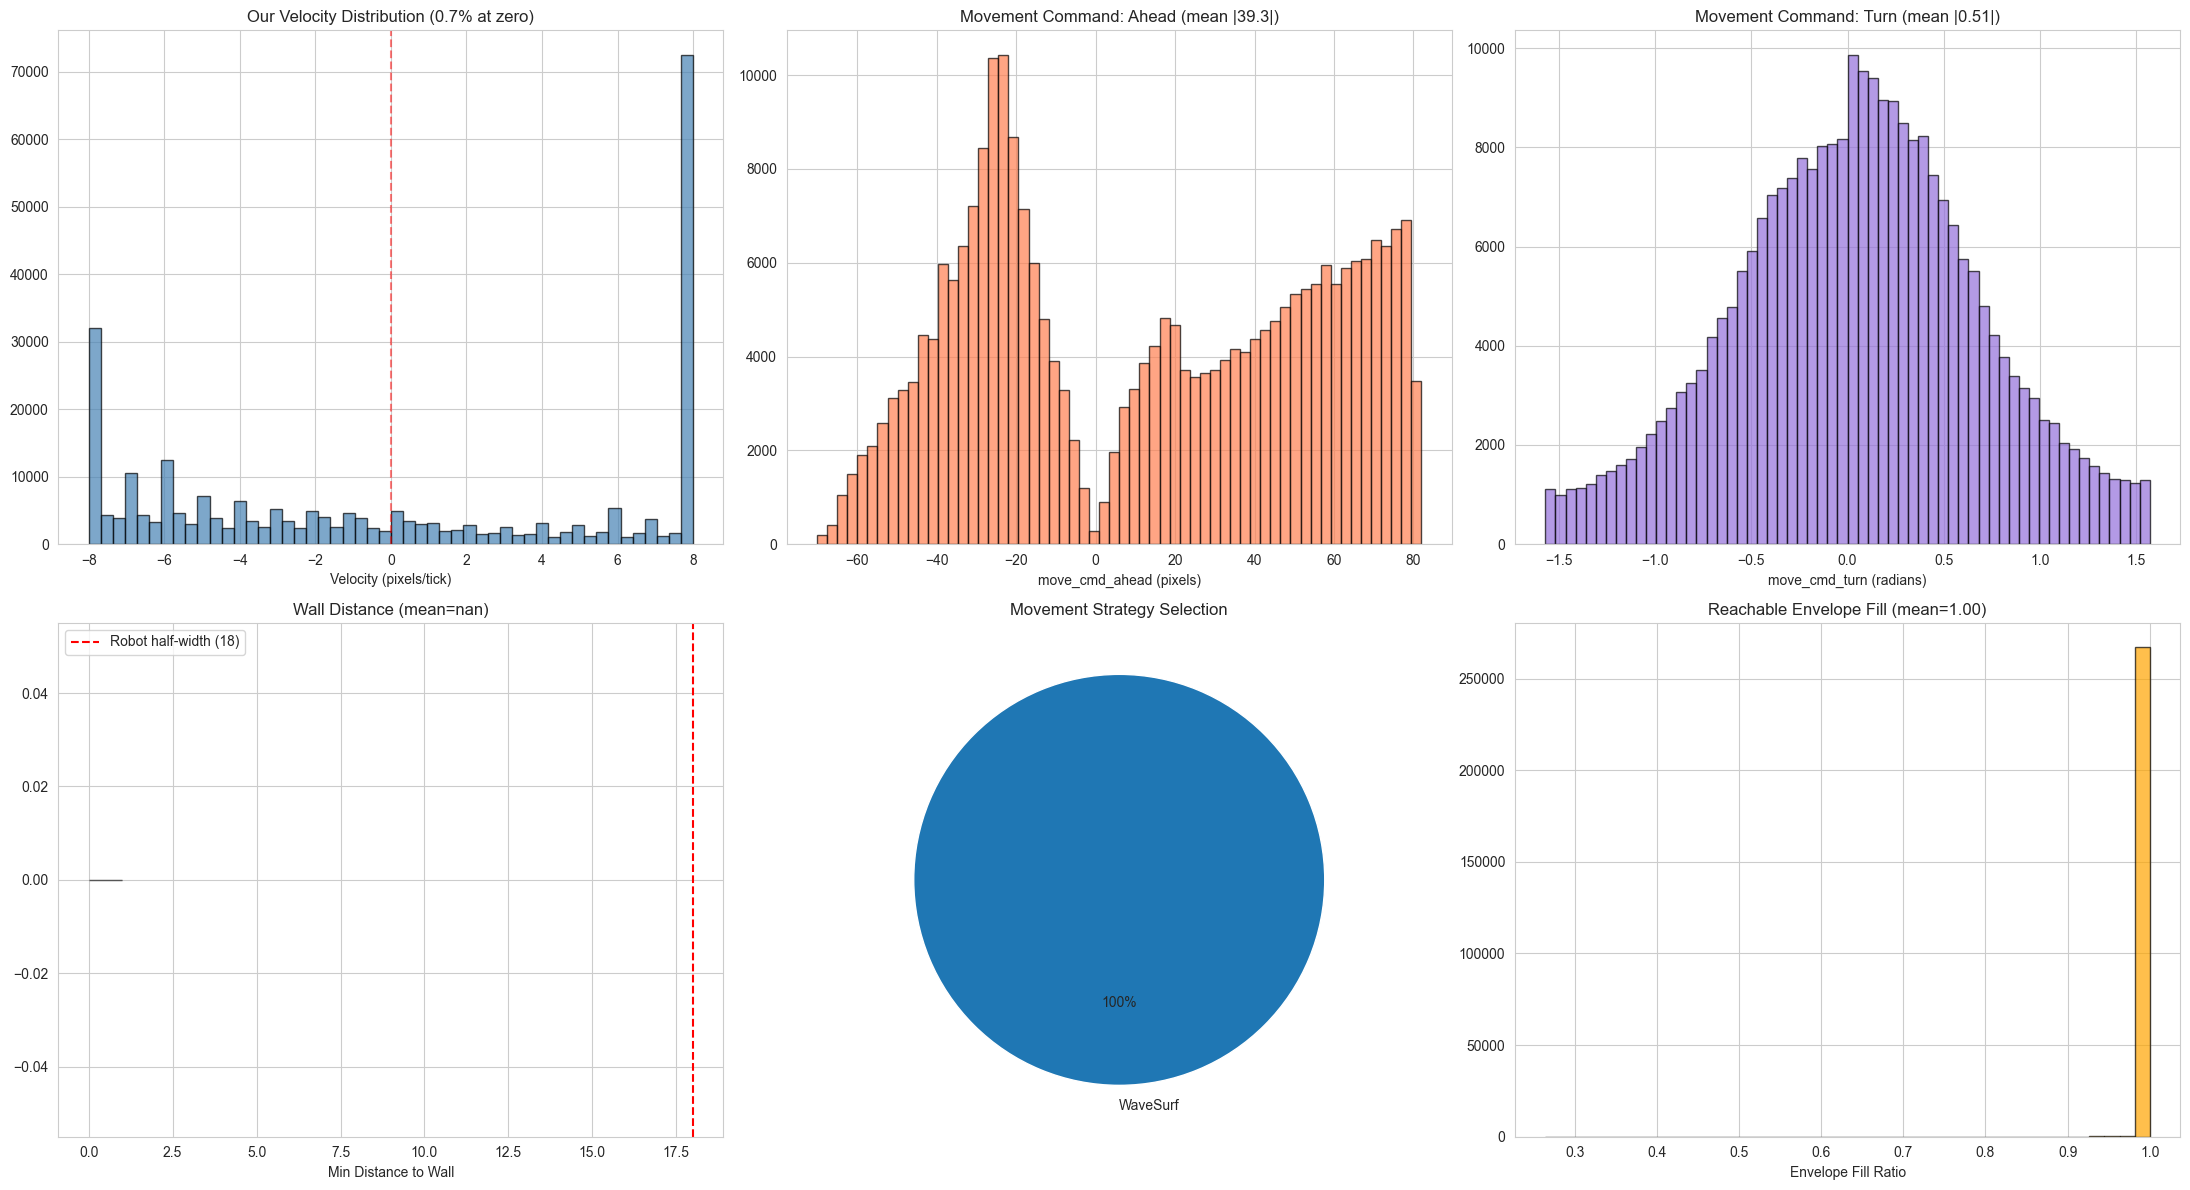

In [2]:
# --- Movement commands & velocity ---
fig, axes = plt.subplots(2, 3, figsize=(22, 12))

# 1. Our velocity distribution
ax = axes[0, 0]
if 'our_velocity' in df.columns:
    df['our_velocity'].hist(ax=ax, bins=50, color='steelblue', alpha=0.7, edgecolor='black')
    ax.axvline(0, color='red', linestyle='--', alpha=0.5)
    pct_zero = (df['our_velocity'] == 0).mean() * 100
    ax.set_title(f'Our Velocity Distribution ({pct_zero:.1f}% at zero)')
    ax.set_xlabel('Velocity (pixels/tick)')
else:
    ax.set_title('our_velocity not found')

# 2. move_cmd_ahead distribution
ax = axes[0, 1]
df['move_cmd_ahead'].hist(ax=ax, bins=60, color='coral', alpha=0.7, edgecolor='black')
ax.set_xlabel('move_cmd_ahead (pixels)')
ax.set_title(f'Movement Command: Ahead (mean |{df.move_cmd_ahead.abs().mean():.1f}|)')

# 3. move_cmd_turn distribution
ax = axes[0, 2]
df['move_cmd_turn'].hist(ax=ax, bins=60, color='mediumpurple', alpha=0.7, edgecolor='black')
ax.set_xlabel('move_cmd_turn (radians)')
ax.set_title(f'Movement Command: Turn (mean |{df.move_cmd_turn.abs().mean():.2f}|)')

# 4. Distance to wall distribution
ax = axes[1, 0]
if 'our_dist_to_wall_min' in df.columns:
    wall = df['our_dist_to_wall_min'].dropna()
    wall.hist(ax=ax, bins=50, color='green', alpha=0.7, edgecolor='black')
    ax.axvline(18, color='red', linestyle='--', label='Robot half-width (18)')
    ax.set_xlabel('Min Distance to Wall')
    ax.set_title(f'Wall Distance (mean={wall.mean():.0f})')
    ax.legend()

# 5. Movement strategy distribution
ax = axes[1, 1]
strat_names = {0: 'WaveSurf', 1: 'MinRisk', 2: 'Orbit'}
strat_counts = df['move_strategy_idx'].map(strat_names).fillna('Other').value_counts()
strat_counts.plot.pie(ax=ax, autopct='%1.0f%%', startangle=90)
ax.set_ylabel('')
ax.set_title('Movement Strategy Selection')

# 6. Envelope fill ratio
ax = axes[1, 2]
if 'envelope_fill_ratio' in df.columns:
    efr = df['envelope_fill_ratio'].dropna()
    efr.hist(ax=ax, bins=40, color='orange', alpha=0.7, edgecolor='black')
    ax.set_xlabel('Envelope Fill Ratio')
    ax.set_title(f'Reachable Envelope Fill (mean={efr.mean():.2f})')

plt.tight_layout()
plt.show()

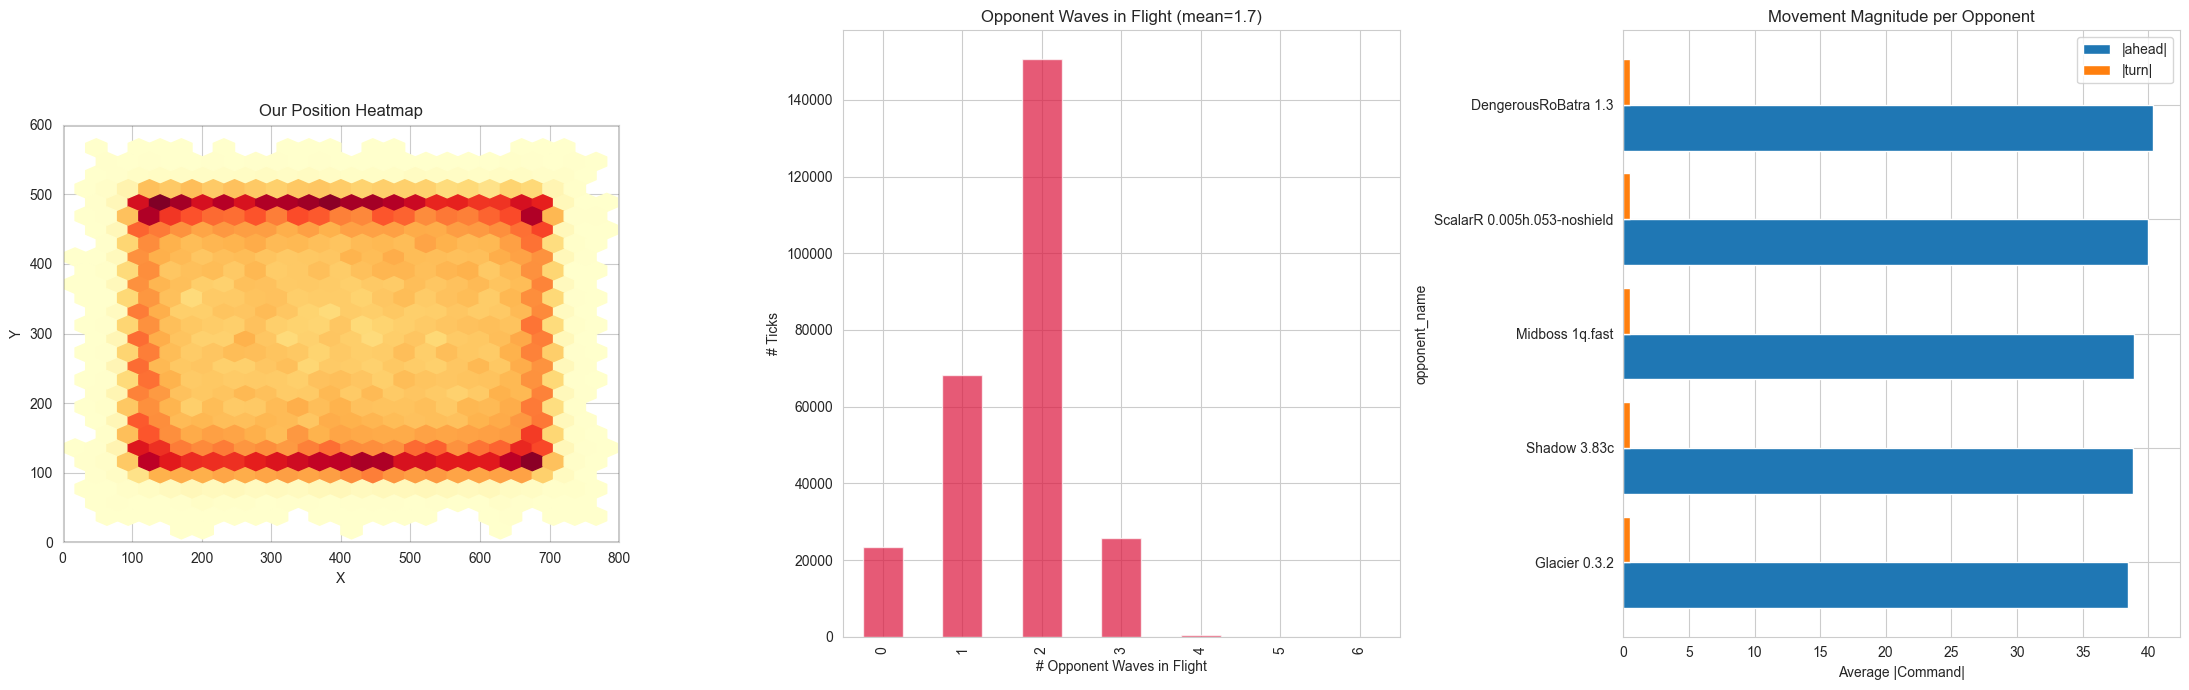

In [3]:
# --- Position heatmap & wave surfing quality ---
fig, axes = plt.subplots(1, 3, figsize=(22, 7))

# 1. Position heatmap
ax = axes[0]
if 'our_x' in df.columns and 'our_y' in df.columns:
    x = df['our_x'].dropna()
    y = df['our_y'].dropna()
    ax.hexbin(x, y, gridsize=25, cmap='YlOrRd', mincnt=1)
    ax.set_xlim(0, 800)
    ax.set_ylim(0, 600)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_title('Our Position Heatmap')
    ax.set_aspect('equal')
    # Draw battlefield border
    ax.plot([0,800,800,0,0], [0,0,600,600,0], 'k-', linewidth=1)
else:
    ax.set_title('Position data not available')

# 2. Opponent waves in flight
ax = axes[1]
if 'n_opponent_waves_in_flight' in df.columns:
    waves = df['n_opponent_waves_in_flight'].dropna()
    waves.value_counts().sort_index().plot.bar(ax=ax, color='crimson', alpha=0.7)
    ax.set_xlabel('# Opponent Waves in Flight')
    ax.set_ylabel('# Ticks')
    ax.set_title(f'Opponent Waves in Flight (mean={waves.mean():.1f})')

# 3. Per-opponent movement command magnitude
ax = axes[2]
opp_move = df.groupby('opponent_name').agg(
    avg_ahead=('move_cmd_ahead', lambda x: x.abs().mean()),
    avg_turn=('move_cmd_turn', lambda x: x.abs().mean()),
).sort_values('avg_ahead')
opp_move.plot.barh(ax=ax, width=0.8)
ax.set_xlabel('Average |Command|')
ax.set_title('Movement Magnitude per Opponent')
ax.legend(['|ahead|', '|turn|'])

plt.tight_layout()
plt.show()

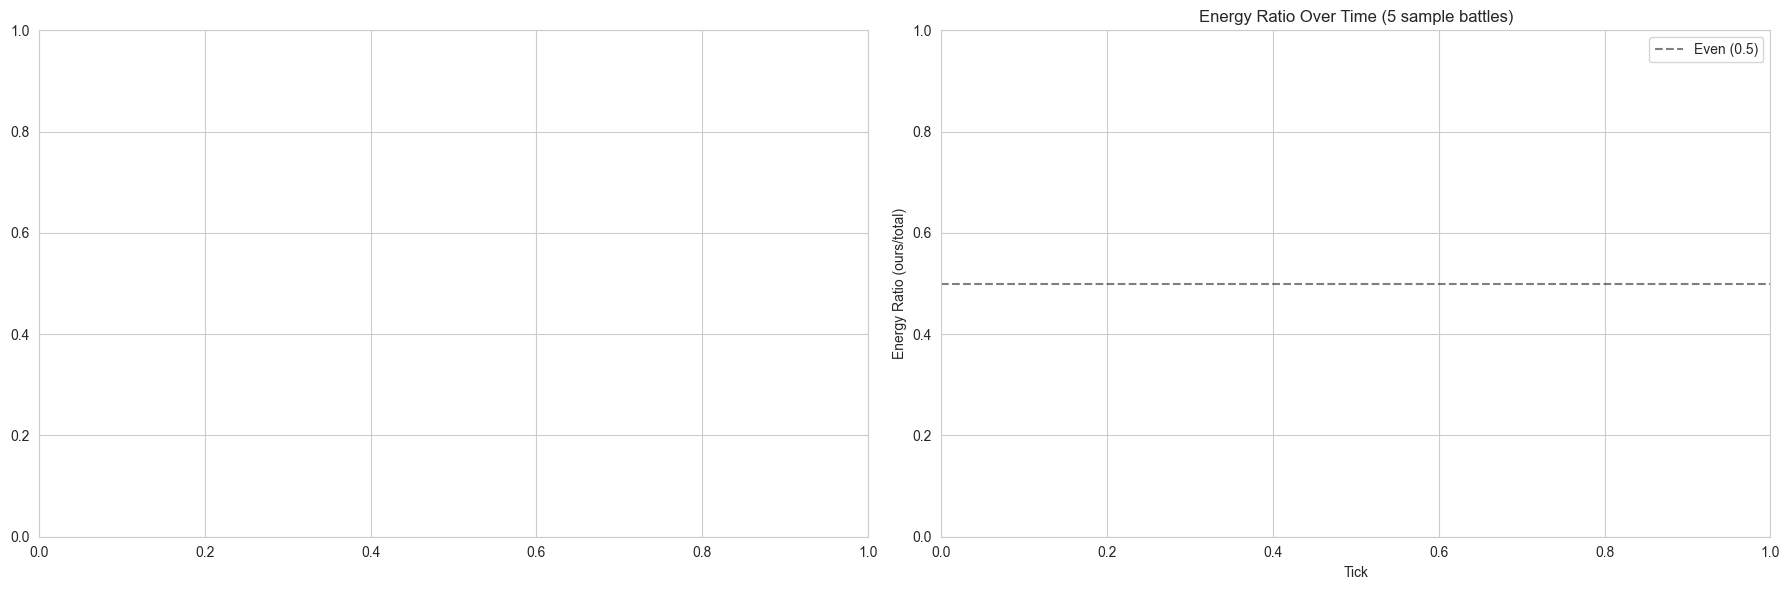

=== Movement Diagnostics ===
Total ticks: 268,377
Avg |velocity|: 5.60 px/tick
Ticks at zero velocity: 0.7%
Avg |move_cmd_ahead|: 39.3 px
Avg |move_cmd_turn|: 0.508 rad
Avg wall distance: nan px
Avg opponent waves in flight: 1.7
Movement strategy 0 (WaveSurf): 100%


In [4]:
# --- Wave surfing timing: do we react before waves arrive? ---
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Opponent wave ETA when we have waves
ax = axes[0]
if 'opponent_wave_eta' in df.columns:
    eta = df['opponent_wave_eta'].dropna()
    eta = eta[eta > 0]
    if len(eta) > 0:
        eta.hist(ax=ax, bins=40, color='tomato', alpha=0.7, edgecolor='black')
        ax.set_xlabel('Ticks Until Wave Arrival')
        ax.set_title(f'Opponent Wave ETA Distribution (mean={eta.mean():.1f} ticks)')
        ax.axvline(5, color='red', linestyle='--', label='Danger zone (5 ticks)')
        ax.legend()

# Energy ratio evolution (proxy for how badly we lose)
ax = axes[1]
if 'energy_ratio' in df.columns:
    # Sample a few battles
    sample_battles = df['battle_id'].value_counts().nlargest(5).index
    for bid in sample_battles:
        bdata = df[df['battle_id'] == bid].sort_values('tick')
        er = bdata['energy_ratio'].dropna()
        if len(er) > 10:
            ax.plot(bdata.loc[er.index, 'tick'], er, alpha=0.5, linewidth=0.8)
    ax.axhline(0.5, color='black', linestyle='--', alpha=0.5, label='Even (0.5)')
    ax.set_xlabel('Tick')
    ax.set_ylabel('Energy Ratio (ours/total)')
    ax.set_title('Energy Ratio Over Time (5 sample battles)')
    ax.legend()
    ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()

# Summary stats
print('=== Movement Diagnostics ===')
print(f'Total ticks: {len(df):,}')
if 'our_velocity' in df.columns:
    print(f'Avg |velocity|: {df.our_velocity.abs().mean():.2f} px/tick')
    print(f'Ticks at zero velocity: {(df.our_velocity==0).mean()*100:.1f}%')
print(f'Avg |move_cmd_ahead|: {df.move_cmd_ahead.abs().mean():.1f} px')
print(f'Avg |move_cmd_turn|: {df.move_cmd_turn.abs().mean():.3f} rad')
if 'our_dist_to_wall_min' in df.columns:
    print(f'Avg wall distance: {df.our_dist_to_wall_min.dropna().mean():.0f} px')
if 'n_opponent_waves_in_flight' in df.columns:
    print(f'Avg opponent waves in flight: {df.n_opponent_waves_in_flight.dropna().mean():.1f}')
print(f'Movement strategy 0 (WaveSurf): {(df.move_strategy_idx==0).mean()*100:.0f}%')